In [1]:
! pip3 install gymnasium[classic_control]

#  CartPole-v1 with Deep Q-Network (DQN)

##  Environment Overview

| Feature              | Description |
|----------------------|-------------|
| **Goal**             | Balance a pole on a moving cart by applying left or right forces |
| **Action Space**     | Discrete:  
- `0`: Push cart to the left  
- `1`: Push cart to the right |
| **Observation Space**| Continuous (4D vector):  
- Cart position  
- Cart velocity  
- Pole angle  
- Pole angular velocity |
| **Reward**           | +1 at each timestep the pole remains upright |
| **Episode Ends If**  |  
- Pole angle exceeds ±12° (~0.209 rad)  
- Cart moves > 2.4 units from the center  
- Episode reaches max steps (500) |

---


What the Agent Learns
The agent observes the 4D state vector:

𝑠
𝑡
=
[
𝑥
,
𝑥
˙
,
𝜃
,
𝜃
˙
]


x: Cart position

𝑥
˙: Cart velocity


θ: Pole angle



θ
˙
 : Pole angular velocity

It must choose an action


a
t
​
 ∈{0,1}

It receives:

Reward
𝑟
𝑡
=
+
1
if it keeps the pole upright

Episode ends if it fails to do so

In [2]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

env = gym.make("CartPole-v1")

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)


# To ensure reproducibility during training, you can fix the random seeds
# by uncommenting the lines below. This makes the results consistent across
# runs, which is helpful for debugging or comparing different approaches.
#
# That said, allowing randomness can be beneficial in practice, as it lets
# the model explore different training trajectories.


# seed = 42
# random.seed(seed)
# torch.manual_seed(seed)
# env.reset(seed=seed)
# env.action_space.seed(seed)
# env.observation_space.seed(seed)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed(seed)

## What is Replay Memory?
Replay Memory, also called Experience Replay, is a critical component in Deep Q-Learning. It helps stabilize and improve learning by breaking the strong correlations between consecutive training samples that naturally occur when an agent interacts with an environment.

##  Why Do We Need It?
- When an RL agent plays a game (like CartPole), each experience depends heavily on the previous one. If we trained directly on this stream of data:

- The data would be highly correlated.

- The training would be unstable.

- The neural network would forget earlier patterns quickly.

- In contrast, neural networks usually learn best from independent, randomly distributed data (this is a key assumption in supervised learning too).

## Replay Memory solves this by:

- Storing all past experiences (state, action, reward, next state).

- Sampling randomly from that memory during training.

- This breaks the correlation and allows more robust and stable updates to the network.



In [3]:
# Define a named tuple called 'Transition'
# It will hold one experience: (state, action, next_state, reward)
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))


class ReplayMemory(object):
    """
    ReplayMemory stores past experiences (transitions) to enable experience replay.
    This helps break correlations in sequential data and improves training stability.
    """

    def __init__(self, capacity):
        """
        Initialize the replay memory.

        Args:
            capacity (int): Maximum number of transitions to store.
        """
        # deque automatically discards the oldest transition when capacity is exceeded
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """
        Save a transition into memory.

        Args:
            *args: A sequence like (state, action, next_state, reward)
        """
        # Store the transition as a namedtuple in the deque
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        """
        Randomly sample a batch of transitions from memory.

        Args:
            batch_size (int): Number of transitions to sample.

        Returns:
            List[Transition]: A list of randomly sampled transitions.
        """
        return random.sample(self.memory, batch_size)

    def __len__(self):
        """
        Return the current size of internal memory (number of stored transitions).
        Useful to check if we have enough samples to train.
        """
        return len(self.memory)


In [4]:
class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        """
        Initialize the Deep Q-Network.

        Args:
            n_observations (int): Size of the input state vector (e.g., 4 for CartPole)
            n_actions (int): Number of possible discrete actions (e.g., 2 for left/right)
        """
        super(DQN, self).__init__()

        # First fully connected layer: input -> 128 hidden units
        self.layer1 = nn.Linear(n_observations, 128)

        # Second fully connected layer: 128 -> 128 hidden units
        self.layer2 = nn.Linear(128, 128)

        # Output layer: 128 -> number of actions
        # Each output neuron gives Q-value for one action
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):


      """
      Forward pass through the network.

      Args:
          x (torch.Tensor): A single state or a batch of states
                            Shape: [batch_size, n_observations]

      Returns:
          torch.Tensor: Q-values for each action
                        Shape: [batch_size, n_actions]
      """
      # Apply ReLU activation after each hidden layer
      x = F.relu(self.layer1(x))  # First hidden layer with ReLU
      x = F.relu(self.layer2(x))  # Second hidden layer with ReLU
      return self.layer3(x)       # Output layer (no activation)



In [5]:
BATCH_SIZE = 128        # Number of transitions sampled per training step
GAMMA = 0.99            # Discount factor for future rewards
EPS_START = 0.9         # Initial epsilon value for exploration
EPS_END = 0.01          # Final epsilon value (after decay)
EPS_DECAY = 2500        # How fast epsilon decays (higher = slower decay)
TAU = 0.005             # Soft update parameter for target network
LR = 3e-4               # Learning rate for the AdamW optimizer


# Get number of actions from gym action space ie 2
n_actions = env.action_space.n
# Get the number of state observations
state, info = env.reset()
n_observations = len(state) # ie 4

policy_net = DQN(n_observations, n_actions).to(device) #The model used for choosing actions
target_net = DQN(n_observations, n_actions).to(device) # A stable target used for computing target Q-values during training
target_net.load_state_dict(policy_net.state_dict()) #Initializes both networks with the same weights



optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000) # upto 10k past transaction


steps_done = 0

def select_action(state):
    global steps_done
    sample = random.random()

    #Computes the decaying epsilon using an exponential decay formula
    eps_threshold = (
        EPS_END + (EPS_START - EPS_END) *
        math.exp(-1. * steps_done / EPS_DECAY)
    )

    steps_done += 1

    # If random value > ε, choose action greedily (from policy_net)
    #Else choose a random action (for exploration)

    if sample > eps_threshold:  # With probability (1 - ε), choose the action with max Q-value (exploit)
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1) # Forward pass to get Q-values and take argmax (best action)
    else:
        # With probability ε, choose a random action (explore)
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)


episode_durations = []


def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())
    plt.legend()

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

## Traning
### Purpose of 'optimize_model()'
This function:

- Samples a batch of experiences from the replay memory.

- Calculates predicted and target Q-values.

- Computes the loss between them.

- Updates the Q-network (policy_net) using gradient descent.

In [6]:
def optimize_model():
    if len(memory) < BATCH_SIZE: # Safety check
        return
    transitions = memory.sample(BATCH_SIZE) #randomly sampled experiences of the form (state, action, next_state, reward).
    batch = Transition(*zip(*transitions)) # tuple of list

    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool) #Boolean mask indicating which transitions are not terminal states.
   # These lines stack individual tensors into batched tensors
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

  # Compute Q-values from the policy network
    state_action_values = policy_net(state_batch).gather(1, action_batch)

#Compute target Q-values from the target network.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

In [7]:
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 600
else:
    num_episodes = 50

for i_episode in range(num_episodes):
    # Initialize the environment and get its state
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    for t in count():
        action = select_action(state) # Chooses action using ε-greedy strategy
        observation, reward, terminated, truncated, _ = env.step(action.item()) # Executes the action
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
            #Smoothly updates target network weights using the TAU parameter to blend current and previous weights.


        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations()
            break



<Figure size 640x480 with 0 Axes>

/tmp/ipython-input-5-822745604.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Complete


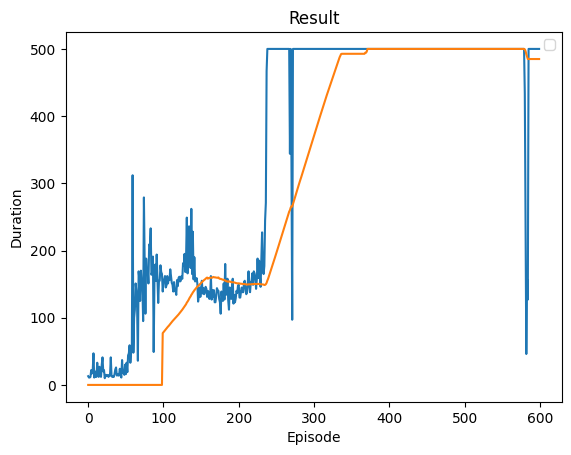

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [8]:
print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()

In [9]:
!sudo apt-get install -y xvfb
!pip install -q pyvirtualdisplay


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.15).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [16]:
from pyvirtualdisplay import Display
import matplotlib.pyplot as plt
import base64
from IPython.display import HTML
import gymnasium as gym
import imageio
import torch

# Start a virtual display (necessary for Colab to render)
display = Display(visible=0, size=(1400, 900))
display.start()

# Create new environment with video rendering
video_env = gym.make("CartPole-v1", render_mode="rgb_array")
video_frames = []

# Reset env
state, _ = video_env.reset()
state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

for _ in range(500):
    with torch.no_grad():
        action = policy_net(state).max(1).indices.view(1, 1)

    # Step in the video_env
    next_obs, _, terminated, truncated, _ = video_env.step(action.item())
    video_frames.append(video_env.render())  #  Save the frame!

    if terminated or truncated:
        break

    # Update state
    state = torch.tensor(next_obs, dtype=torch.float32, device=device).unsqueeze(0)

video_env.close()

# Save the video
video_path = "/content/cartpole_dqn.mp4"
imageio.mimsave(video_path, video_frames, fps=30)

# Display the video
def display_video(filename):
    video = open(filename, "rb").read()
    encoded = base64.b64encode(video).decode("ascii")
    return HTML(f'''
        <video width="640" height="480" controls>
            <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
        </video>
    ''')

display_video(video_path)
